# U.S. Medical Insurance Costs

My first independent data analysis project, provided by Codecademy as part of their Data Scientist: Analytics Specialist Career Path. The purpose of this project is to identify correlations between how much people pay in medical insurance in the United States and six other factors.

In [43]:
# Import Dependencies
import csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [44]:
# Bring in and load insurance.csv
# Data is brought in as a list of dictionaries
with open('insurance.csv', newline='') as insurance_costs:
    insurance_data = list(csv.DictReader(insurance_costs))
    for row in insurance_data:
        print(row)

{'age': '19', 'sex': 'female', 'bmi': '27.9', 'children': '0', 'smoker': 'yes', 'region': 'southwest', 'charges': '16884.924'}
{'age': '18', 'sex': 'male', 'bmi': '33.77', 'children': '1', 'smoker': 'no', 'region': 'southeast', 'charges': '1725.5523'}
{'age': '28', 'sex': 'male', 'bmi': '33', 'children': '3', 'smoker': 'no', 'region': 'southeast', 'charges': '4449.462'}
{'age': '33', 'sex': 'male', 'bmi': '22.705', 'children': '0', 'smoker': 'no', 'region': 'northwest', 'charges': '21984.47061'}
{'age': '32', 'sex': 'male', 'bmi': '28.88', 'children': '0', 'smoker': 'no', 'region': 'northwest', 'charges': '3866.8552'}
{'age': '31', 'sex': 'female', 'bmi': '25.74', 'children': '0', 'smoker': 'no', 'region': 'southeast', 'charges': '3756.6216'}
{'age': '46', 'sex': 'female', 'bmi': '33.44', 'children': '1', 'smoker': 'no', 'region': 'southeast', 'charges': '8240.5896'}
{'age': '37', 'sex': 'female', 'bmi': '27.74', 'children': '3', 'smoker': 'no', 'region': 'northwest', 'charges': '7281.

In [45]:
# Data columns saved separately as lists using list comprehensions
age = [int(row['age']) for row in insurance_data]
sex = [row['sex'] for row in insurance_data]
bmi = [float(row['bmi']) for row in insurance_data]
children = [int(row['children']) for row in insurance_data]
smoker = [row['smoker'] for row in insurance_data]
region = [row['region'] for row in insurance_data]
charges = [round(float(row['charges']), 2) for row in insurance_data]




# Checking the distribution of the values in the data columns

In [46]:
# Use Counter from collections to count the number of times the various values occur in the columns
# Charges column not accounted for
age_counts = Counter(age)
sex_counts = Counter(sex)
bmi_counts = Counter(bmi)
children_counts = Counter(children)
smoker_counts = Counter(smoker)
region_counts = Counter(region)

print(age_counts)
print(sex_counts)
print(bmi_counts)
print(children_counts)
print(smoker_counts)
print(region_counts)

# All Counter objects saved to a list
column_variable_counts = [age_counts, sex_counts, bmi_counts, children_counts, smoker_counts, region_counts]

# Names describing columns, to be used for bar chart labels
column_variable_names = ["Names", "Sexes", "BMI", "Children", "Smokers", "Regions"]


Counter({18: 69, 19: 68, 46: 29, 52: 29, 48: 29, 20: 29, 45: 29, 47: 29, 51: 29, 50: 29, 28: 28, 25: 28, 23: 28, 27: 28, 22: 28, 26: 28, 24: 28, 21: 28, 53: 28, 54: 28, 49: 28, 31: 27, 30: 27, 41: 27, 40: 27, 43: 27, 44: 27, 29: 27, 42: 27, 33: 26, 32: 26, 56: 26, 34: 26, 55: 26, 57: 26, 37: 25, 59: 25, 35: 25, 38: 25, 36: 25, 58: 25, 39: 25, 60: 23, 62: 23, 63: 23, 61: 23, 64: 22})
Counter({'male': 676, 'female': 662})
Counter({32.3: 13, 28.31: 9, 28.88: 8, 34.1: 8, 30.8: 8, 30.875: 8, 31.35: 8, 30.495: 8, 32.775: 7, 35.2: 7, 27.36: 7, 34.8: 7, 25.46: 7, 32.11: 7, 30.59: 7, 38.06: 7, 24.32: 7, 27.645: 7, 33.33: 7, 25.8: 7, 33.0: 6, 27.74: 6, 29.83: 6, 26.6: 6, 33.63: 6, 35.53: 6, 19.95: 6, 30.115: 6, 29.92: 6, 27.5: 6, 28.595: 6, 37.1: 6, 25.175: 6, 26.41: 6, 30.2: 6, 31.73: 6, 25.84: 5, 30.78: 5, 31.92: 5, 28.025: 5, 26.315: 5, 31.825: 5, 33.66: 5, 28.9: 5, 28.5: 5, 29.7: 5, 28.975: 5, 28.785: 5, 25.3: 5, 36.85: 5, 29.64: 5, 33.155: 5, 33.345: 5, 27.835: 5, 23.21: 5, 32.395: 5, 34.2:

In [47]:
# Counter objects are internally rearranged according to keys in ascending order
# First indented line is generated by Google AI
sorted_counts = []
for column in column_variable_counts:
    column = dict(sorted(column.items(), key = lambda item: item[0]))
    sorted_counts.append(column)

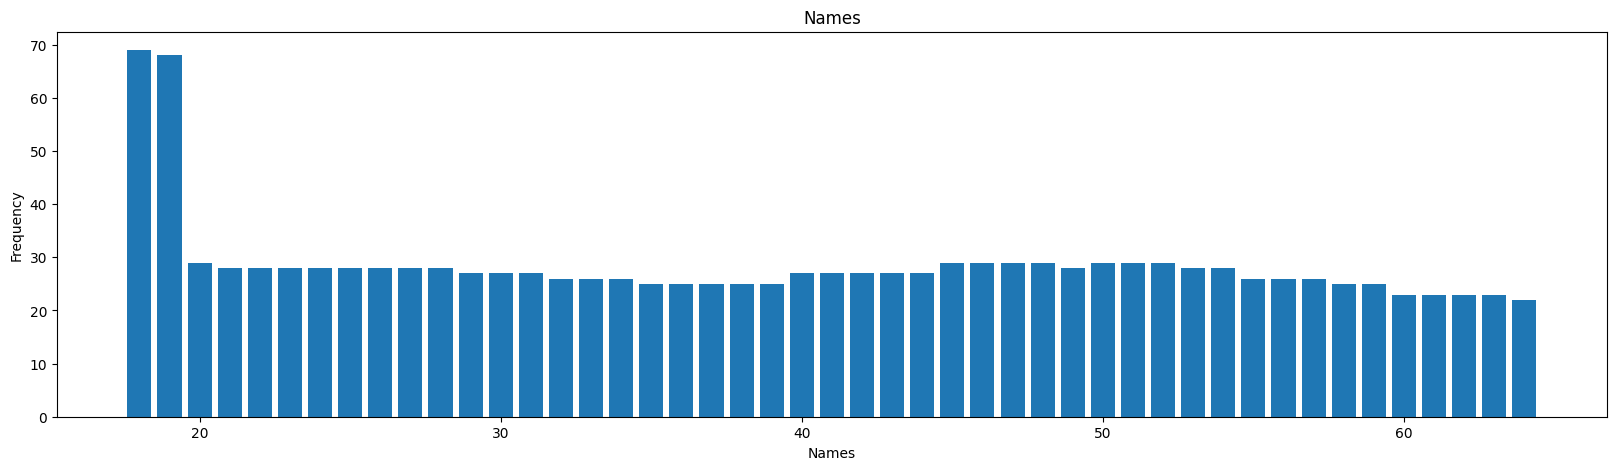

<Figure size 640x480 with 0 Axes>

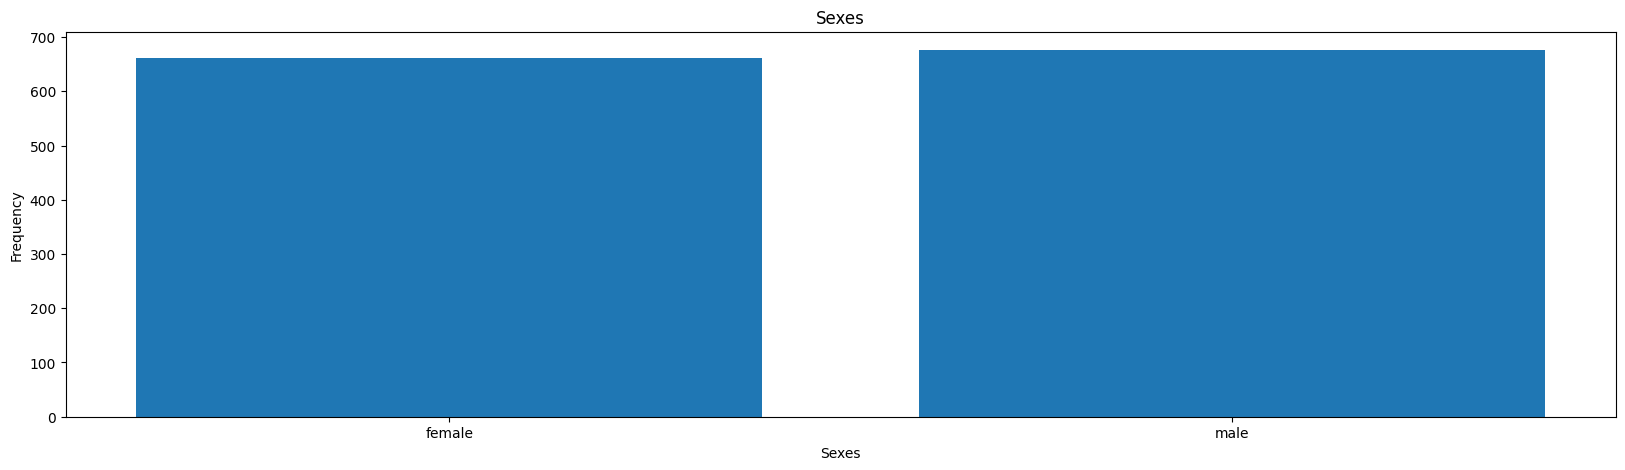

<Figure size 640x480 with 0 Axes>

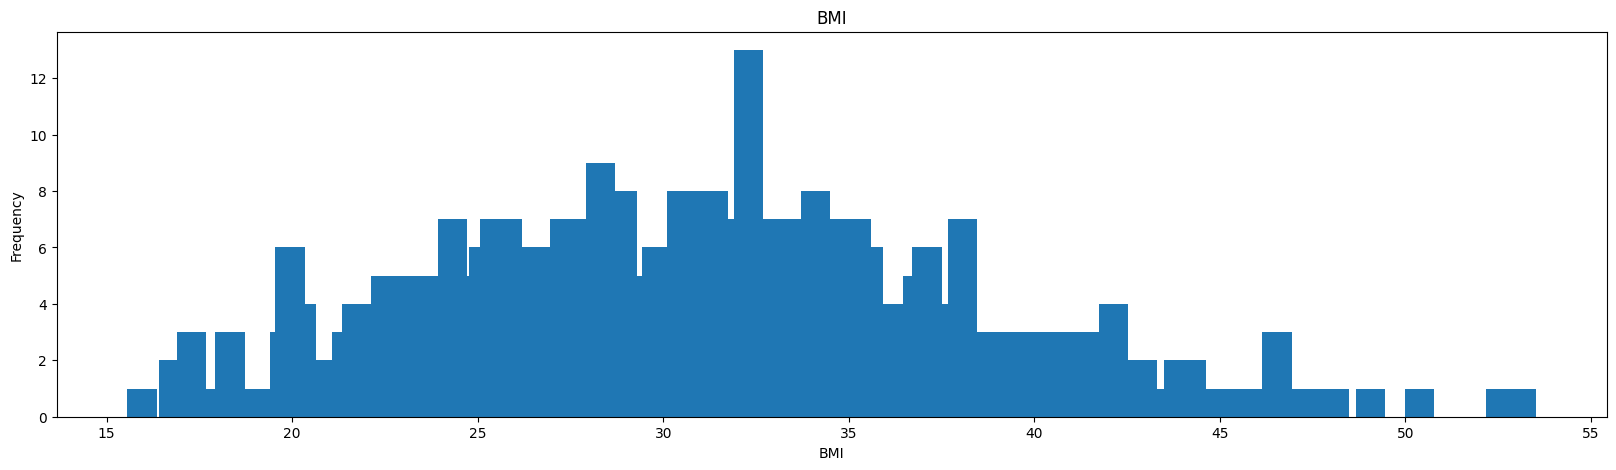

<Figure size 640x480 with 0 Axes>

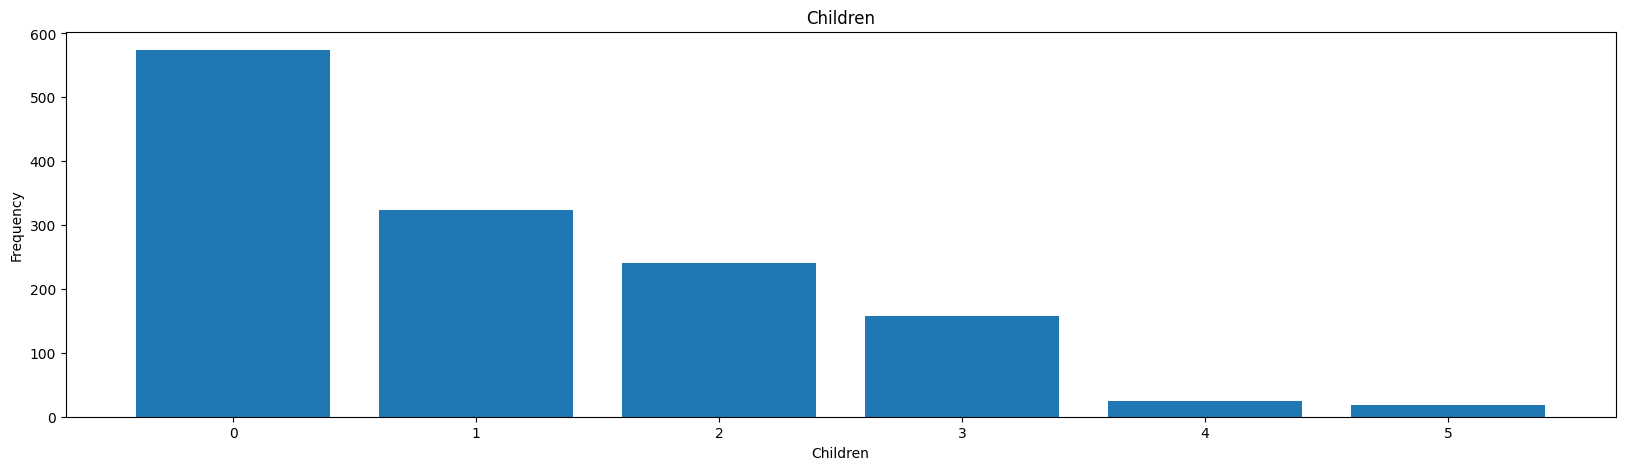

<Figure size 640x480 with 0 Axes>

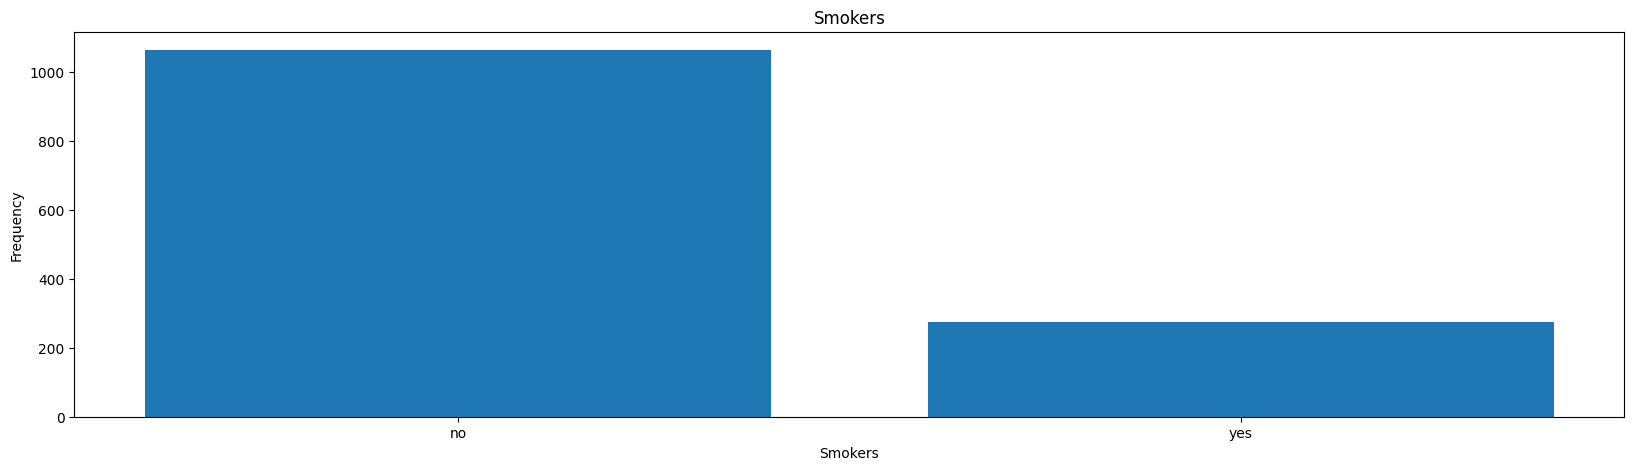

<Figure size 640x480 with 0 Axes>

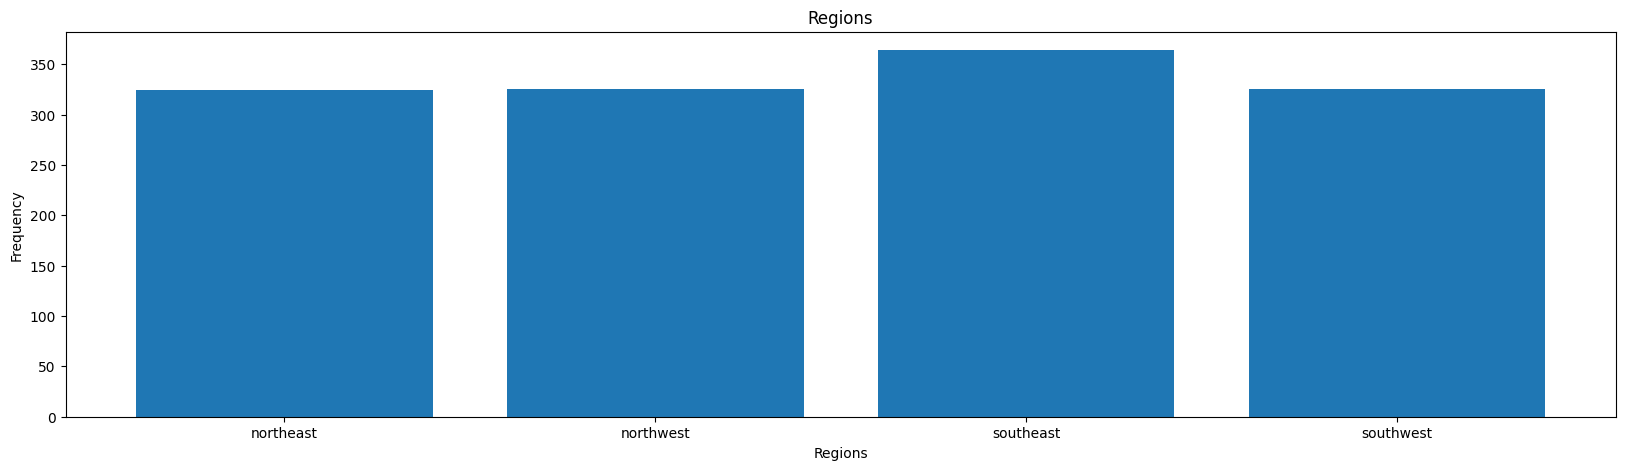

<Figure size 640x480 with 0 Axes>

In [48]:
# Loop generates a bar chart for each of the columns (not including charges)
# The purpose of this procedure is to check that the data does not unduly represent certain populations
# more than others (for instance, having twice as many women as men), although this is not completely avoidable
for i in range(len(sorted_counts)):
    plt.figure(figsize=(20,5))
    plt.bar(sorted_counts[i].keys(), sorted_counts[i].values())
    plt.title(column_variable_names[i])
    plt.xlabel(column_variable_names[i])
    plt.ylabel("Frequency")
    plt.show()
    plt.clf()


# Beginning Analysis

In [49]:
# Looking for correlation between age and charges
# Begin by computing some statistics
        
# Average age
average_age = np.average(age)
print("Average Age: " + str(round(average_age,0)))

# Average charges
average_charges = np.average(charges)
print("Average Charges: " + str(round(average_charges, 2)))

Average Age: 39.0
Average Charges: 13270.42


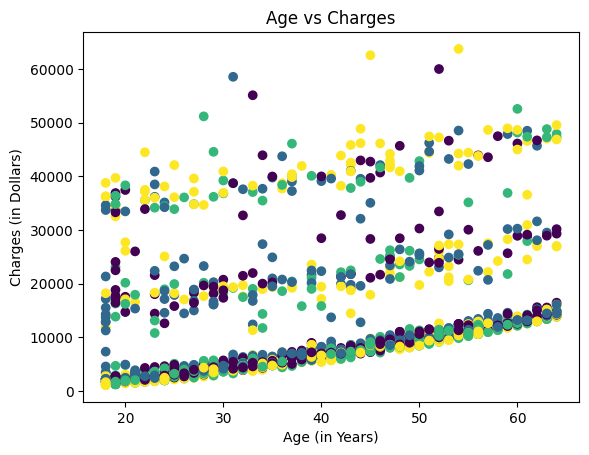

In [50]:
numerical_region = []
for i in range(len(region)):
    if region[i] == 'northwest':
        numerical_region.append(0)
    elif region[i] == 'northeast':
        numerical_region.append(1)
    elif region[i] == 'southwest':
        numerical_region.append(2)
    else:
        numerical_region.append(3)

plt.scatter(age, charges, c = numerical_region)
plt.title("Age vs Charges")
plt.xlabel("Age (in Years)")
plt.ylabel("Charges (in Dollars)")
plt.show()

Above is a scatter plot that plots age against charges. As can be seen from the graph, charges do seem to increase in a roughly linear fashion as age increases. What's curious is that the data breaks up into three parallel lines of data. The bottom line, which contains individuals having lower charge, is more compact than the other two lines. Attempts were made understand why the data breaks up this way by color coding the points according to the values in the other columns. No pattern was revealed, so more information about these individuals may be needed to clear this up. The scatterplot above color codes the points according to region.

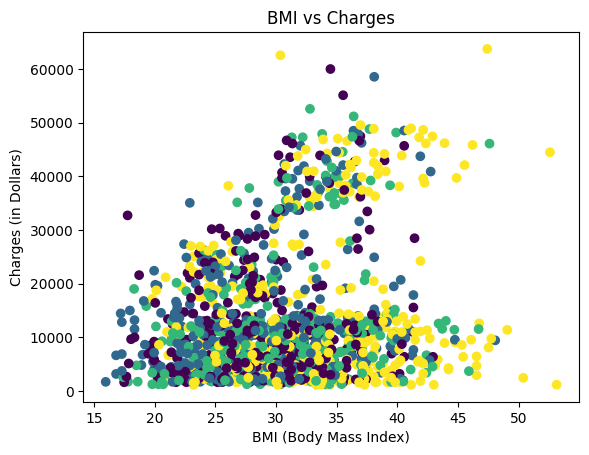

In [60]:
plt.scatter(bmi, charges, c = numerical_region)
plt.title("BMI vs Charges")
plt.xlabel("BMI (Body Mass Index)")
plt.ylabel("Charges (in Dollars)")
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x246b066bed0>,
 'caps': [<matplotlib.lines.Line2D at 0x246afbe4910>,
 'boxes': [<matplotlib.lines.Line2D at 0x246afbe3910>,
 'medians': [<matplotlib.lines.Line2D at 0x246b1aa1890>,
 'fliers': [<matplotlib.lines.Line2D at 0x246b1aa34d0>,
 'means': []}

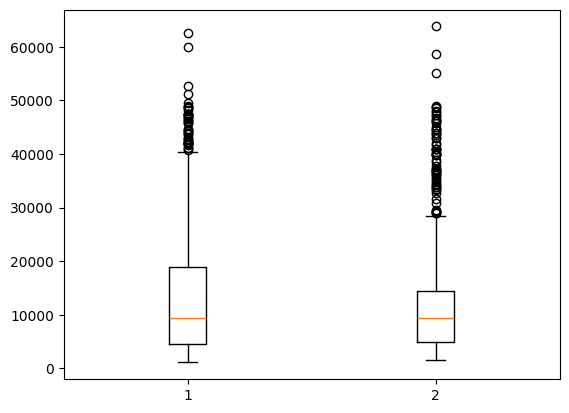

In [ ]:
# Sex against charges
male_patients = []
female_patients = []
for entry in insurance_data:
    if entry['sex'] == 'male':
        male_patients.append(entry)
    else:
        female_patients.append(entry)
male_charges = [round(float(entry['charges']),2) for entry in male_patients]
female_charges = [round(float(entry['charges']),2) for entry in female_patients]



plt.boxplot([male_charges, female_charges])


{'whiskers': [<matplotlib.lines.Line2D at 0x246aeb2ecd0>,
 'caps': [<matplotlib.lines.Line2D at 0x246aeb2de90>,
 'boxes': [<matplotlib.lines.Line2D at 0x2469da3c850>,
 'medians': [<matplotlib.lines.Line2D at 0x246aeb2e7d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x24698ddb410>,
 'means': []}

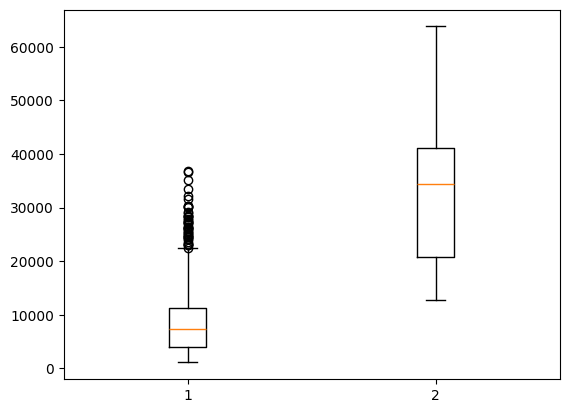

In [67]:
# Smoker against charges
non_smoker_patients = []
smoker_patients = []
for entry in insurance_data:
    if entry['smoker'] == 'no':
        non_smoker_patients.append(entry)
    else:
        smoker_patients.append(entry)
non_smoker_charges = [round(float(entry['charges']),2) for entry in non_smoker_patients]
smoker_charges = [round(float(entry['charges']),2) for entry in smoker_patients]



plt.boxplot([non_smoker_charges, smoker_charges])

{'whiskers': [<matplotlib.lines.Line2D at 0x246afcf3bd0>,
 'caps': [<matplotlib.lines.Line2D at 0x246afcf9a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x246afd14850>,
 'medians': [<matplotlib.lines.Line2D at 0x246afcfb210>,
 'fliers': [<matplotlib.lines.Line2D at 0x246afcf9d10>,
 'means': []}

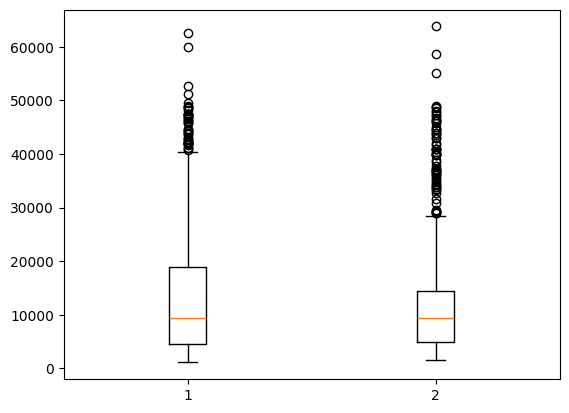

In [64]:
# Region againsts charges
male_patients = []
female_patients = []
for entry in insurance_data:
    if entry['sex'] == 'male':
        male_patients.append(entry)
    else:
        female_patients.append(entry)
male_charges = [round(float(entry['charges']),2) for entry in male_patients]
female_charges = [round(float(entry['charges']),2) for entry in female_patients]



plt.boxplot([male_charges, female_charges])